# Final Configurations (Unified Views and Calcification-Only)
* **Image Preprocessing**:
  * CLAHE + Median Blur
* **Image Views**:
  * Unified (CC + MLO)
* **Lesions**:
  * Calcification-Only

### Models:
1. VGG16
2. ResNet50
3. DenseNet121
4. MobileNetV2
5. EfficientNet-B0

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 643, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 643 (delta 67), reused 130 (delta 49), pack-reused 483 (from 1)
Receiving objects: 100% (643/643), 20.95 MiB | 17.83 MiB/s, done.
Resolving deltas: 100% (316/316), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.final_results_functions import generate_final_results_df, store_final_results
from src.calibration_scores_functions import *
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, FINAL_EPOCHS, PREDICTION_THRESHOLD

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training, validation and testing datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training, validation and testing metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")
test_df = pd.read_csv(dataset_root + "/test_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

In [ ]:
# Unified view and Calcification Only data
# Train
train_final_df = train_df.loc[train_df['abnormality type'] == 'calcification'][['patient_id', 'image view', 'abnormality type', 'new_image_path', 'pathology']]
# Validation
val_final_df = val_df.loc[val_df['abnormality type'] == 'calcification'][['patient_id', 'image view', 'abnormality type', 'new_image_path', 'pathology']]
# Test
test_final_df = test_df.loc[test_df['abnormality type'] == 'calcification'][['patient_id', 'image view', 'abnormality type', 'new_image_path', 'pathology']]

In [ ]:
# Verify Unified view and Calcification-Only dataframes
print(f"Training Image View: {train_final_df['image view'].value_counts()}")
print(f"Training Abnormality Type: {train_final_df['abnormality type'].value_counts()}")
print("")
print(f"Validation Image View: {val_final_df['image view'].value_counts()}")
print(f"Validation Abnormality Type: {val_final_df['abnormality type'].value_counts()}")
print("")
print(f"Testing Image View: {test_final_df['image view'].value_counts()}")
print(f"Testing Abnormality Type: {test_final_df['abnormality type'].value_counts()}")

Training Image View: image view
MLO    621
CC     547
Name: count, dtype: int64
Training Abnormality Type: abnormality type
calcification    1168
Name: count, dtype: int64

Validation Image View: image view
MLO    162
CC     154
Name: count, dtype: int64
Validation Abnormality Type: abnormality type
calcification    316
Name: count, dtype: int64

Testing Image View: image view
MLO    199
CC     187
Name: count, dtype: int64
Testing Abnormality Type: abnormality type
calcification    386
Name: count, dtype: int64


In [ ]:
# Print pathology distribution Unified view and Calcification-Only
print(train_final_df['pathology'].value_counts())
print(val_final_df['pathology'].value_counts())
print(test_final_df['pathology'].value_counts())

pathology
0.0    767
1.0    401
Name: count, dtype: int64
pathology
0.0    214
1.0    102
Name: count, dtype: int64
pathology
0.0    217
1.0    169
Name: count, dtype: int64


In [ ]:
# Testing true labels Unified view and Calcification-Only
test_true_labels = test_final_df['pathology'].to_numpy()
# True labels tensor
test_true_labels_tensor = tf.convert_to_tensor(test_final_df['pathology'], dtype=tf.float32)
test_true_labels_tensor = tf.reshape(test_true_labels_tensor, (-1, 1))
test_true_labels_tensor_squeezed = tf.squeeze(test_true_labels_tensor)

In [ ]:
# Print true labels tensors' shapes Unified view and Calcification-Only
print(test_true_labels_tensor.shape)
print(test_true_labels_tensor_squeezed.shape)

(386, 1)
(386,)


In [ ]:
# CSV Files to store all final results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Final_Results/final_results_calcification.csv"

In [ ]:
# Buffer size for shuffling and no. of training samples in training dataset for Unified view and Calcification-Only
BUFFER_SIZE = len(train_final_df)
TOTAL_TRAINING_SAMPLES = len(train_final_df)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_final_df, CLASSES, TOTAL_TRAINING_SAMPLES)

In [ ]:
# Image Preprocessing CLAHE + Median Blur + (resizing + model-specific normalization) preprocessing
clahe_median_blur_preprocessor = IMAGE_PREPROCESSORS['clahe_median_blur']

## Unified view and Calcification-Only lesion Final Configurations

#### tf.data Dataset Preparation for Unified view and Calcification-Only Final Configurations

In [ ]:
# Generate training, validation and testing datasets for final
train_dataset = dataset_preparation(train_final_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset = dataset_preparation(val_final_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)
test_dataset = dataset_preparation(test_final_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

## VGG16

In [ ]:
# Select the VGG16 model
vgg16_model = select_model('vgg16')
# Print model summary
vgg16_model.summary()
# Compile and train the VGG16 model with training data
vgg16, train_time_vgg16, peak_memory_vgg16 = train_selected_model(vgg16_model,
                                                                  train_dataset,
                                                                  val_dataset,
                                                                  FINAL_EPOCHS,
                                                                  early_stopping,
                                                                  class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 30s 521ms/step - accuracy: 0.5394 - auc: 0.5317 - loss: 1.0670 - precision: 0.3734 - recall: 0.5037 - val_accuracy: 0.6139 - val_auc: 0.5399 - val_loss: 0.7074 - val_precision: 0.3571 - val_recall: 0.2451
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 563ms/step - accuracy: 0.6062 - auc: 0.5695 - loss: 0.8651 - precision: 0.4289 - recall: 0.4439 - val_accuracy: 0.6108 - val_auc: 0.5747 - val_loss: 0.6917 - val_precision: 0.3765 - val_recall: 0.3137
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 493ms/step - accuracy: 0.6053 - auc: 0.5915 - loss: 0.8244 - precision: 0.4333 - recall: 0.4863 - val_accuracy: 0.6804 - val_auc: 0.5803 - val_loss: 0.6243 - val_precision: 0.5106 - val_recall: 0.2353
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 499ms/step - accuracy: 0.6147 - auc: 0.6027 - loss: 0.7638 - precision: 0.4401 - recall: 0.4489 - val_accuracy: 0.6519 - val_auc: 0.6036 - val_loss: 0.6229 - val_precision: 0.4375 - val_recall: 0.2745
Epoch 5/20
37/37 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16, predictions_vgg16, metrics_dict_vgg16, infer_time_vgg16 = generate_predictions_and_evaluations(vgg16,
                                                                                                             test_dataset,
                                                                                                             test_true_labels,
                                                                                                             PREDICTION_THRESHOLD)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.6710 - auc: 0.6838 - loss: 0.5551 - precision: 0.7561 - recall: 0.3669


In [ ]:
# Temperature for VGG16 (Initial)
temperature_vgg16 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for VGG16
optimized_temperature_vgg16 = temperature_scaling(logits_vgg16, test_true_labels_tensor, temperature_vgg16)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_vgg16 = logits_vgg16 / optimized_temperature_vgg16

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_vgg16 = tfp.stats.expected_calibration_error(
      10,
      logits_vgg16,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_vgg16 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_vgg16,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_vgg16.numpy())
print(ece_after_scaling_vgg16.numpy())

0.43782377
0.43782377


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_vgg16 = tf.nn.sigmoid(logits_vgg16)
pred_calib_probabilities_vgg16 = tf.nn.sigmoid(scaled_logits_vgg16)

# Calculate Brier Score
brier_score_before_scaling_vgg16 = compute_brier_score(pred_probabilities_vgg16, test_true_labels_tensor)
brier_score_after_scaling_vgg16 = compute_brier_score(pred_calib_probabilities_vgg16, test_true_labels_tensor)

print(brier_score_before_scaling_vgg16.numpy())
print(brier_score_after_scaling_vgg16.numpy())

0.19378275
0.1931166


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_results_df = generate_final_results_df(
    model_name='VGG16',
    view='Unified-View',
    lesion='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_vgg16,
    train_time=train_time_vgg16,
    infer_time=infer_time_vgg16,
    peak_memory=peak_memory_vgg16,
    ece_before_scaling=ece_before_scaling_vgg16.numpy(),
    ece_after_scaling=ece_after_scaling_vgg16.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_vgg16.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_vgg16.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, vgg16_results_df)

Saved final results


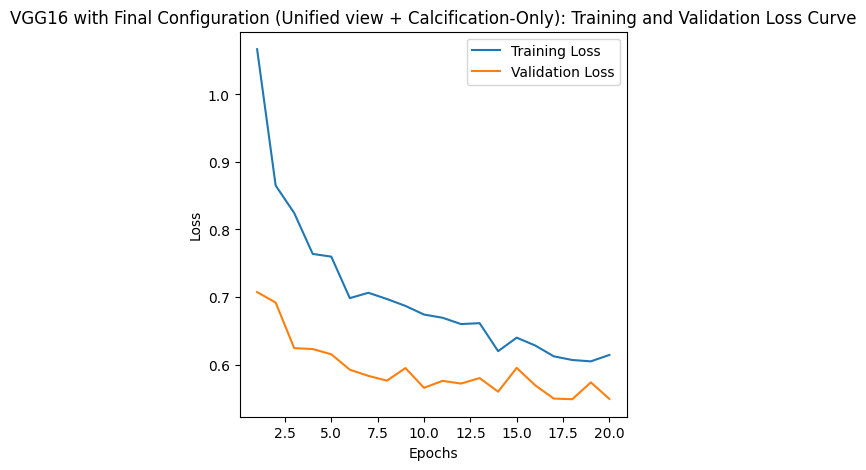

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16.history, 'VGG16', 'Final Configuration (Unified view + Calcification-Only)')

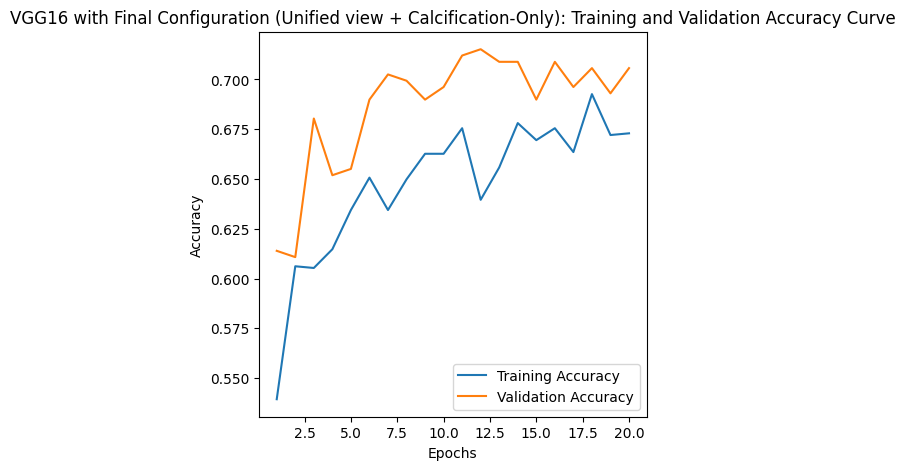

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16.history, 'VGG16', 'Final Configuration (Unified view + Calcification-Only)')

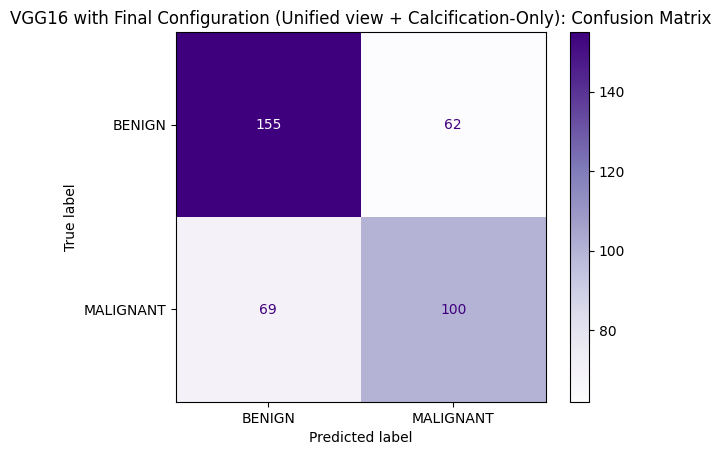

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_vgg16, 'VGG16', 'Final Configuration (Unified view + Calcification-Only)')

In [ ]:
# Save the trained model
vgg16.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/vgg16_final_configuration_unified_calcification.keras")

## ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model = select_model('resnet50')
# Print model summary
resnet50_model.summary()
# Compile and train the ResNet50 model with training data
resnet50, train_time_resnet50, peak_memory_resnet50 = train_selected_model(resnet50_model,
                                                                           train_dataset,
                                                                           val_dataset,
                                                                           FINAL_EPOCHS,
                                                                           early_stopping,
                                                                           class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 36s 563ms/step - accuracy: 0.6447 - auc: 0.6197 - loss: 0.6798 - precision: 0.4816 - recall: 0.4564 - val_accuracy: 0.7120 - val_auc: 0.6623 - val_loss: 0.5195 - val_precision: 0.6486 - val_recall: 0.2353
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 484ms/step - accuracy: 0.6498 - auc: 0.6588 - loss: 0.6274 - precision: 0.4895 - recall: 0.4663 - val_accuracy: 0.7184 - val_auc: 0.7453 - val_loss: 0.5479 - val_precision: 0.5890 - val_recall: 0.4216
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 23s 512ms/step - accuracy: 0.6909 - auc: 0.7013 - loss: 0.5845 - precision: 0.5549 - recall: 0.5037 - val_accuracy: 0.7468 - val_auc: 0.7328 - val_loss: 0.5112 - val_precision: 0.7200 - val_recall: 0.3529
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 484ms/step - accuracy: 0.6832 - auc: 0.6868 - loss: 0.5993 - precision: 0.5444 - recall: 0.4738 - val_accuracy: 0.7405 - val_auc: 0.7361 - val_loss: 0.5143 - val_precision: 0.6923 - val_recall: 0.3529
Epoch 5/20
37/37 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50, predictions_resnet50, metrics_dict_resnet50, infer_time_resnet50 = generate_predictions_and_evaluations(resnet50,
                                                                                                                         test_dataset,
                                                                                                                         test_true_labels,
                                                                                                                         PREDICTION_THRESHOLD)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 373ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step - accuracy: 0.6399 - auc: 0.6811 - loss: 0.5482 - precision: 0.7273 - recall: 0.2840


In [ ]:
# Temperature for ResNet50 (Initial)
temperature_resnet50 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for ResNet50
optimized_temperature_resnet50 = temperature_scaling(logits_resnet50, test_true_labels_tensor, temperature_resnet50)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_resnet50 = logits_resnet50 / optimized_temperature_resnet50

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_resnet50 = tfp.stats.expected_calibration_error(
      10,
      logits_resnet50,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_resnet50 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_resnet50,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_resnet50.numpy())
print(ece_after_scaling_resnet50.numpy())

0.43782377
0.43782377


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_resnet50 = tf.nn.sigmoid(logits_resnet50)
pred_calib_probabilities_resnet50 = tf.nn.sigmoid(scaled_logits_resnet50)

# Calculate Brier Score
brier_score_before_scaling_resnet50 = compute_brier_score(pred_probabilities_resnet50, test_true_labels_tensor)
brier_score_after_scaling_resnet50 = compute_brier_score(pred_calib_probabilities_resnet50, test_true_labels_tensor)

print(brier_score_before_scaling_resnet50.numpy())
print(brier_score_after_scaling_resnet50.numpy())

0.19044787
0.19047908


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_results_df = generate_final_results_df(
    model_name='ResNet50',
    view='Unified-View',
    lesion='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_resnet50,
    train_time=train_time_resnet50,
    infer_time=infer_time_resnet50,
    peak_memory=peak_memory_resnet50,
    ece_before_scaling=ece_before_scaling_resnet50.numpy(),
    ece_after_scaling=ece_after_scaling_resnet50.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_resnet50.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_resnet50.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, resnet50_results_df)

Saved final results


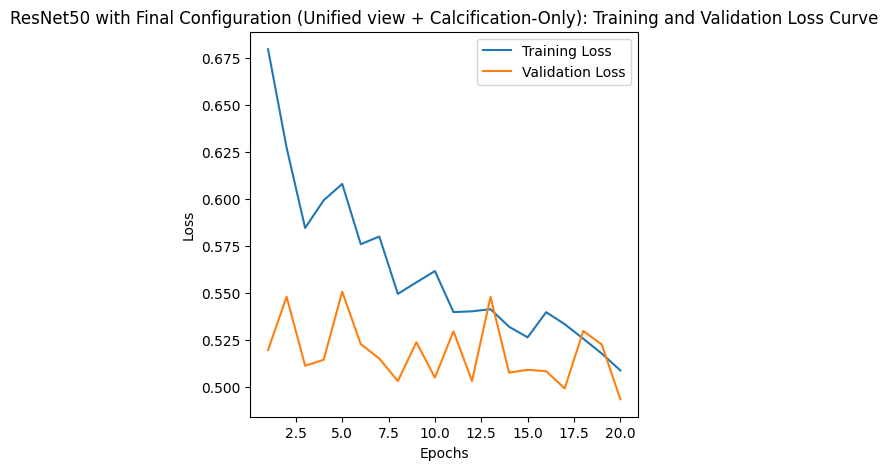

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50.history, 'ResNet50', 'Final Configuration (Unified view + Calcification-Only)')

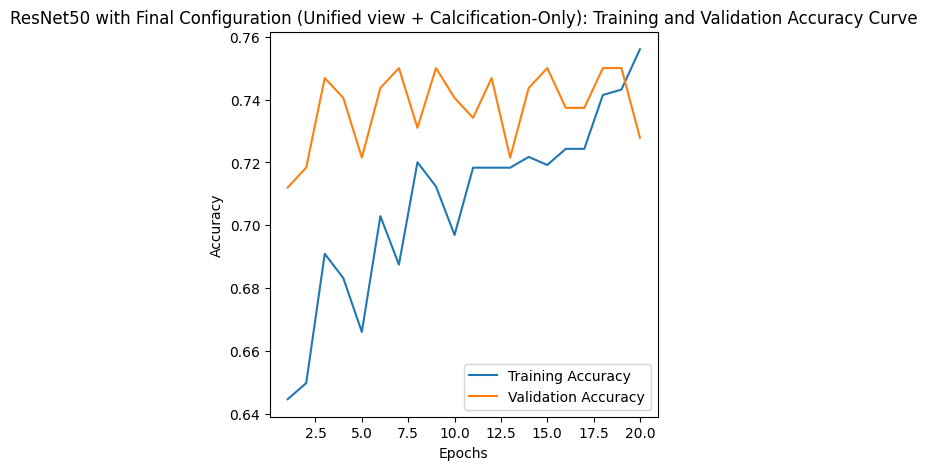

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50.history, 'ResNet50', 'Final Configuration (Unified view + Calcification-Only)')

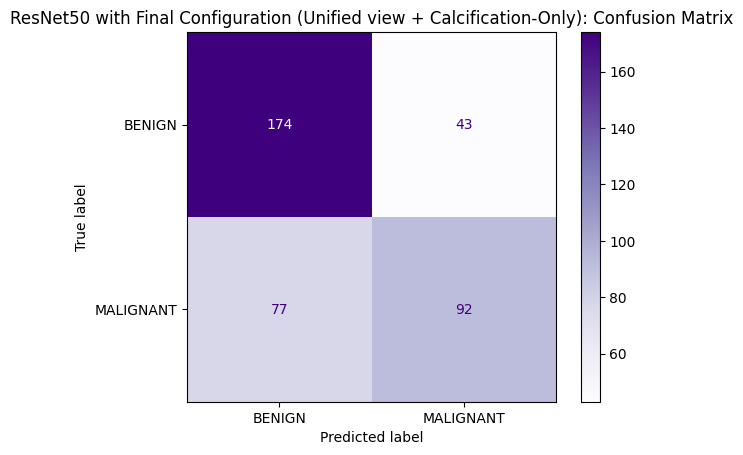

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_resnet50, 'ResNet50', 'Final Configuration (Unified view + Calcification-Only)')

In [ ]:
# Save the trained model
resnet50.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/resnet50_final_configuration_unified_calcification.keras")

## DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model = select_model('densenet121')
# Print model summary
densenet121_model.summary()
# Compile and train the DenseNet121 model with training data
densenet121, train_time_densenet121, peak_memory_densenet121 = train_selected_model(densenet121_model,
                                                                                    train_dataset,
                                                                                    val_dataset,
                                                                                    FINAL_EPOCHS,
                                                                                    early_stopping,
                                                                                    class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 682ms/step - accuracy: 0.5848 - auc: 0.5650 - loss: 1.3637 - precision: 0.4121 - recall: 0.4913 - val_accuracy: 0.6994 - val_auc: 0.5812 - val_loss: 0.6669 - val_precision: 0.6296 - val_recall: 0.1667
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 569ms/step - accuracy: 0.6010 - auc: 0.5741 - loss: 1.1446 - precision: 0.4242 - recall: 0.4539 - val_accuracy: 0.6930 - val_auc: 0.6359 - val_loss: 0.6879 - val_precision: 0.5352 - val_recall: 0.3725
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 549ms/step - accuracy: 0.6147 - auc: 0.5931 - loss: 0.9967 - precision: 0.4437 - recall: 0.4813 - val_accuracy: 0.7215 - val_auc: 0.6242 - val_loss: 0.6412 - val_precision: 0.6667 - val_recall: 0.2745
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 26s 546ms/step - accuracy: 0.6276 - auc: 0.5896 - loss: 0.9574 - precision: 0.4555 - recall: 0.4339 - val_accuracy: 0.6899 - val_auc: 0.6724 - val_loss: 0.6397 - val_precision: 0.5333 - val_recall: 0.3137
Epoch 5/20
37/37 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121, predictions_densenet121, metrics_dict_densenet121, infer_time_densenet121 = generate_predictions_and_evaluations(densenet121,
                                                                                                                                     test_dataset,
                                                                                                                                     test_true_labels,
                                                                                                                                     PREDICTION_THRESHOLD)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 687ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.5777 - auc: 0.5850 - loss: 0.6319 - precision: 0.6154 - recall: 0.0947


In [ ]:
# Temperature for DenseNet121 (Initial)
temperature_densenet121 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for DenseNet121
optimized_temperature_densenet121 = temperature_scaling(logits_densenet121, test_true_labels_tensor, temperature_densenet121)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_densenet121 = logits_densenet121 / optimized_temperature_densenet121

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_densenet121 = tfp.stats.expected_calibration_error(
      10,
      logits_densenet121,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_densenet121 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_densenet121,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_densenet121.numpy())
print(ece_after_scaling_densenet121.numpy())

0.43782377
0.43782377


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_densenet121 = tf.nn.sigmoid(logits_densenet121)
pred_calib_probabilities_densenet121 = tf.nn.sigmoid(scaled_logits_densenet121)

# Calculate Brier Score
brier_score_before_scaling_densenet121 = compute_brier_score(pred_probabilities_densenet121, test_true_labels_tensor)
brier_score_after_scaling_densenet121 = compute_brier_score(pred_calib_probabilities_densenet121, test_true_labels_tensor)

print(brier_score_before_scaling_densenet121.numpy())
print(brier_score_after_scaling_densenet121.numpy())

0.22220635
0.21968813


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_results_df = generate_final_results_df(
    model_name='DenseNet121',
    view='Unified-View',
    lesion='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_densenet121,
    train_time=train_time_densenet121,
    infer_time=infer_time_densenet121,
    peak_memory=peak_memory_densenet121,
    ece_before_scaling=ece_before_scaling_densenet121.numpy(),
    ece_after_scaling=ece_after_scaling_densenet121.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_densenet121.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_densenet121.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, densenet121_results_df)

Saved final results


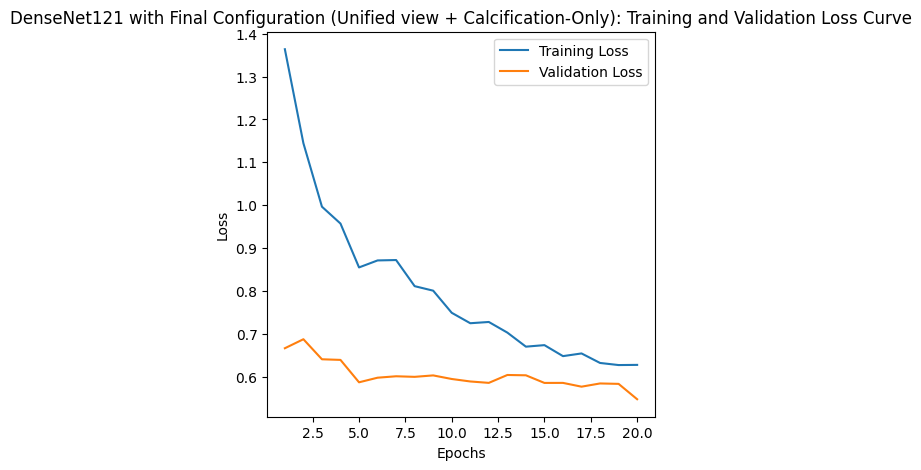

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121.history, 'DenseNet121', 'Final Configuration (Unified view + Calcification-Only)')

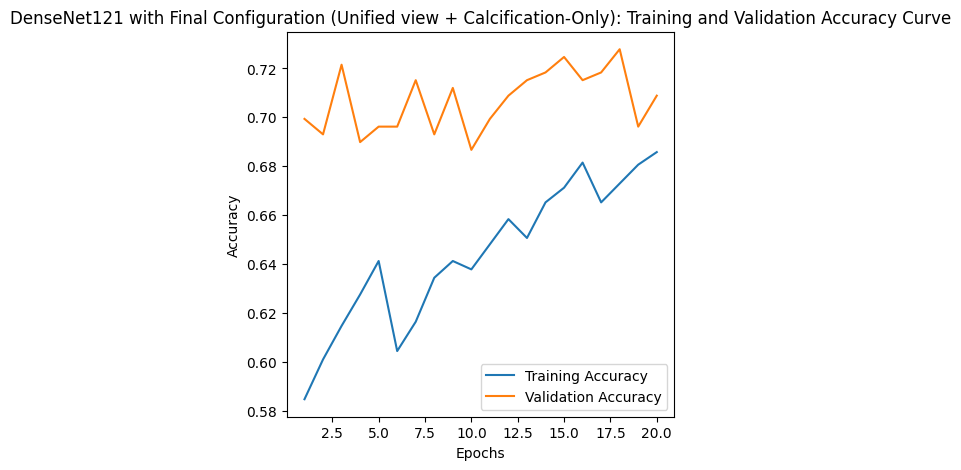

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121.history, 'DenseNet121', 'Final Configuration (Unified view + Calcification-Only)')

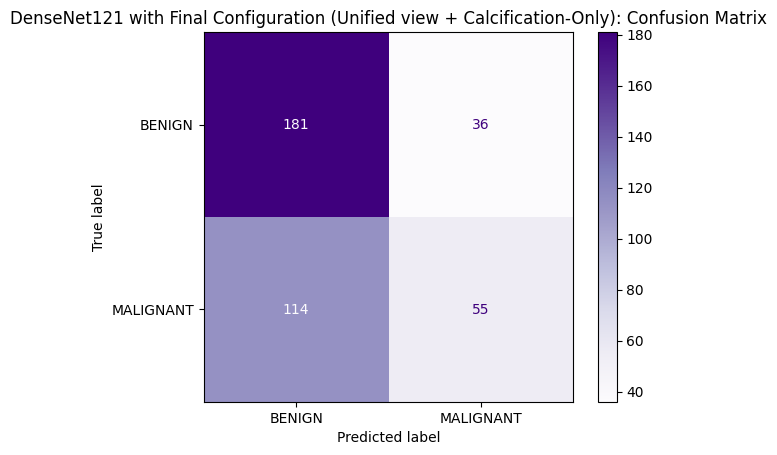

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_densenet121, 'DenseNet121', 'Final Configuration (Unified view + Calcification-Only)')

In [ ]:
# Save the trained model
densenet121.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/densenet121_final_configuration_unified_calcification.keras")

## MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model = select_model('mobilenetv2')
# Print model summary
mobilenetv2_model.summary()
# Compile and train the MobileNetV2 model with training data
mobilenetv2, train_time_mobilenetv2, peak_memory_mobilenetv2 = train_selected_model(mobilenetv2_model,
                                                                                    train_dataset,
                                                                                    val_dataset,
                                                                                    FINAL_EPOCHS,
                                                                                    early_stopping,
                                                                                    class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 31s 474ms/step - accuracy: 0.6156 - auc: 0.5977 - loss: 0.7307 - precision: 0.4391 - recall: 0.4314 - val_accuracy: 0.6867 - val_auc: 0.5941 - val_loss: 0.6162 - val_precision: 0.5600 - val_recall: 0.1373
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.6353 - auc: 0.6170 - loss: 0.6807 - precision: 0.4606 - recall: 0.3641 - val_accuracy: 0.6709 - val_auc: 0.6302 - val_loss: 0.6828 - val_precision: 0.4853 - val_recall: 0.3235
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 430ms/step - accuracy: 0.6524 - auc: 0.6044 - loss: 0.6782 - precision: 0.4919 - recall: 0.3791 - val_accuracy: 0.6962 - val_auc: 0.6030 - val_loss: 0.6354 - val_precision: 0.5577 - val_recall: 0.2843
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.6610 - auc: 0.6297 - loss: 0.6681 - precision: 0.5080 - recall: 0.3965 - val_accuracy: 0.6835 - val_auc: 0.6305 - val_loss: 0.6622 - val_precision: 0.5152 - val_recall: 0.3333
Epoch 5/20
37/37 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2, predictions_mobilenetv2, metrics_dict_mobilenetv2, infer_time_mobilenetv2 = generate_predictions_and_evaluations(mobilenetv2,
                                                                                                                                     test_dataset,
                                                                                                                                     test_true_labels,
                                                                                                                                     PREDICTION_THRESHOLD)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.5933 - auc: 0.6029 - loss: 0.6437 - precision: 0.6579 - recall: 0.1479


In [ ]:
# Temperature for MobileNetV2 (Initial)
temperature_mobilenetv2 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for MobileNetV2
optimized_temperature_mobilenetv2 = temperature_scaling(logits_mobilenetv2, test_true_labels_tensor, temperature_mobilenetv2)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_mobilenetv2 = logits_mobilenetv2 / optimized_temperature_mobilenetv2

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_mobilenetv2 = tfp.stats.expected_calibration_error(
      10,
      logits_mobilenetv2,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_mobilenetv2 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_mobilenetv2,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_mobilenetv2.numpy())
print(ece_after_scaling_mobilenetv2.numpy())

0.43782377
0.43782377


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_mobilenetv2 = tf.nn.sigmoid(logits_mobilenetv2)
pred_calib_probabilities_mobilenetv2 = tf.nn.sigmoid(scaled_logits_mobilenetv2)

# Calculate Brier Score
brier_score_before_scaling_mobilenetv2 = compute_brier_score(pred_probabilities_mobilenetv2, test_true_labels_tensor)
brier_score_after_scaling_mobilenetv2 = compute_brier_score(pred_calib_probabilities_mobilenetv2, test_true_labels_tensor)

print(brier_score_before_scaling_mobilenetv2.numpy())
print(brier_score_after_scaling_mobilenetv2.numpy())

0.22606373
0.2256492


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_results_df = generate_final_results_df(
    model_name='MobileNetV2',
    view='Unified-View',
    lesion='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2,
    train_time=train_time_mobilenetv2,
    infer_time=infer_time_mobilenetv2,
    peak_memory=peak_memory_mobilenetv2,
    ece_before_scaling=ece_before_scaling_mobilenetv2.numpy(),
    ece_after_scaling=ece_after_scaling_mobilenetv2.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_mobilenetv2.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_mobilenetv2.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, mobilenetv2_results_df)

Saved final results


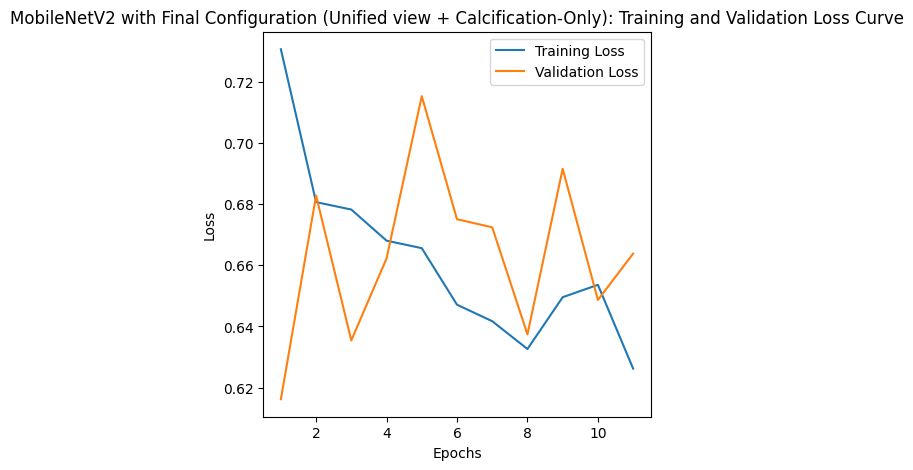

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2.history, 'MobileNetV2', 'Final Configuration (Unified view + Calcification-Only)')

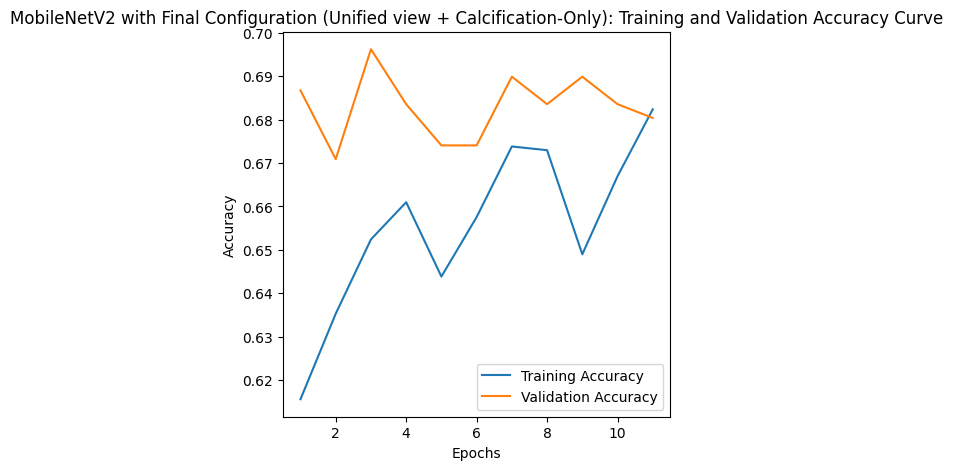

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2.history, 'MobileNetV2', 'Final Configuration (Unified view + Calcification-Only)')

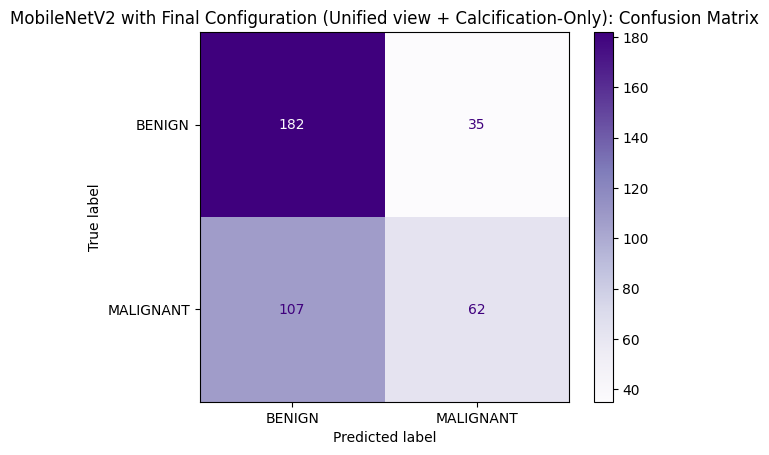

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_mobilenetv2, 'MobileNetV2', 'Final Configuration (Unified view + Calcification-Only)')

In [ ]:
# Save the trained model
mobilenetv2.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/mobilenetv2_final_configuration_unified_calcification.keras")

## EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model = select_model('efficientnetb0')
# Print model summary
efficientnetb0_model.summary()
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0, train_time_efficientnetb0, peak_memory_efficientnetb0 = train_selected_model(efficientnetb0_model,
                                                                                             train_dataset,
                                                                                             val_dataset,
                                                                                             FINAL_EPOCHS,
                                                                                             early_stopping,
                                                                                             class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 583ms/step - accuracy: 0.6267 - auc: 0.5543 - loss: 0.6797 - precision: 0.3841 - recall: 0.1446 - val_accuracy: 0.6962 - val_auc: 0.7174 - val_loss: 0.6252 - val_precision: 0.5385 - val_recall: 0.4118
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 477ms/step - accuracy: 0.6601 - auc: 0.6619 - loss: 0.6145 - precision: 0.5075 - recall: 0.3392 - val_accuracy: 0.6709 - val_auc: 0.7215 - val_loss: 0.6343 - val_precision: 0.4912 - val_recall: 0.5490
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.6832 - auc: 0.6846 - loss: 0.6036 - precision: 0.5471 - recall: 0.4489 - val_accuracy: 0.7342 - val_auc: 0.6933 - val_loss: 0.5728 - val_precision: 0.6500 - val_recall: 0.3824
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 484ms/step - accuracy: 0.6901 - auc: 0.6816 - loss: 0.5889 - precision: 0.5661 - recall: 0.4165 - val_accuracy: 0.7247 - val_auc: 0.6783 - val_loss: 0.5598 - val_precision: 0.6531 - val_recall: 0.3137
Epoch 5/20
37/37 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0, predictions_efficientnetb0, metrics_dict_efficientnetb0, infer_time_efficientnetb0 = generate_predictions_and_evaluations(efficientnetb0,
                                                                                                                                                 test_dataset,
                                                                                                                                                 test_true_labels,
                                                                                                                                                 PREDICTION_THRESHOLD)

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 389ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.6632 - auc: 0.7028 - loss: 0.5387 - precision: 0.7600 - recall: 0.3373


In [ ]:
# Temperature for EfficientNet-B0 (Initial)
temperature_efficientnetb0 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for EfficientNet-B0
optimized_temperature_efficientnetb0 = temperature_scaling(logits_efficientnetb0, test_true_labels_tensor, temperature_efficientnetb0)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_efficientnetb0 = logits_efficientnetb0 / optimized_temperature_efficientnetb0

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_efficientnetb0 = tfp.stats.expected_calibration_error(
      10,
      logits_efficientnetb0,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_efficientnetb0 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_efficientnetb0,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_efficientnetb0.numpy())
print(ece_after_scaling_efficientnetb0.numpy())

0.43782377
0.43782377


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_efficientnetb0 = tf.nn.sigmoid(logits_efficientnetb0)
pred_calib_probabilities_efficientnetb0 = tf.nn.sigmoid(scaled_logits_efficientnetb0)

# Calculate Brier Score
brier_score_before_scaling_efficientnetb0 = compute_brier_score(pred_probabilities_efficientnetb0, test_true_labels_tensor)
brier_score_after_scaling_efficientnetb0 = compute_brier_score(pred_calib_probabilities_efficientnetb0, test_true_labels_tensor)

print(brier_score_before_scaling_efficientnetb0.numpy())
print(brier_score_after_scaling_efficientnetb0.numpy())

0.18598114
0.18527246


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_results_df = generate_final_results_df(
    model_name='EfficientNet-B0',
    view='Unified-View',
    lesion='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0,
    train_time=train_time_efficientnetb0,
    infer_time=infer_time_efficientnetb0,
    peak_memory=peak_memory_efficientnetb0,
    ece_before_scaling=ece_before_scaling_efficientnetb0.numpy(),
    ece_after_scaling=ece_after_scaling_efficientnetb0.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_efficientnetb0.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_efficientnetb0.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, efficientnetb0_results_df)

Saved final results


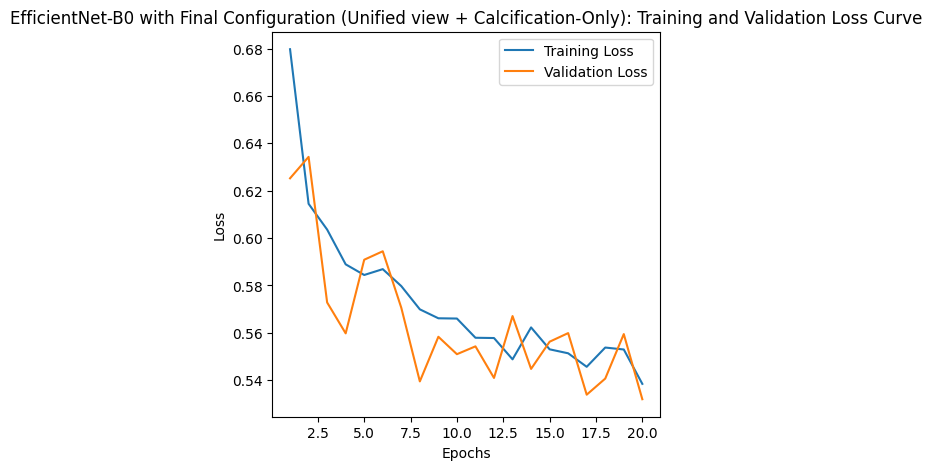

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0.history, 'EfficientNet-B0', 'Final Configuration (Unified view + Calcification-Only)')

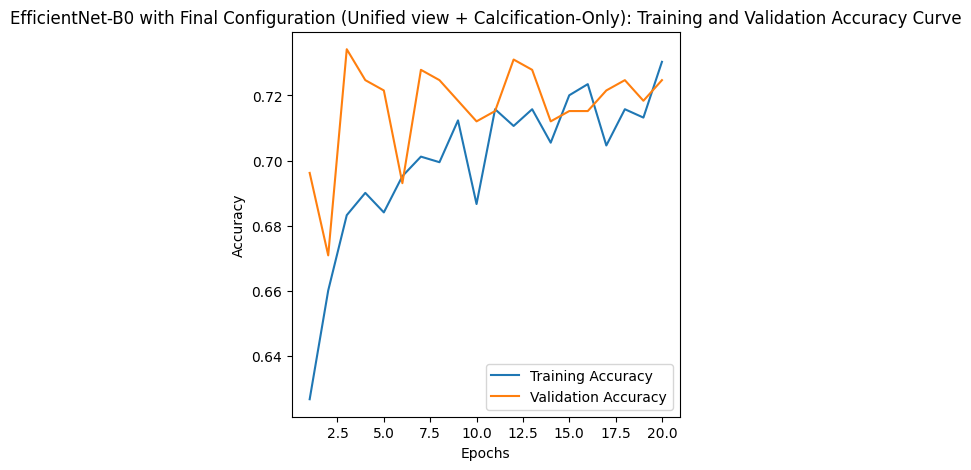

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0.history, 'EfficientNet-B0', 'Final Configuration (Unified view + Calcification-Only)')

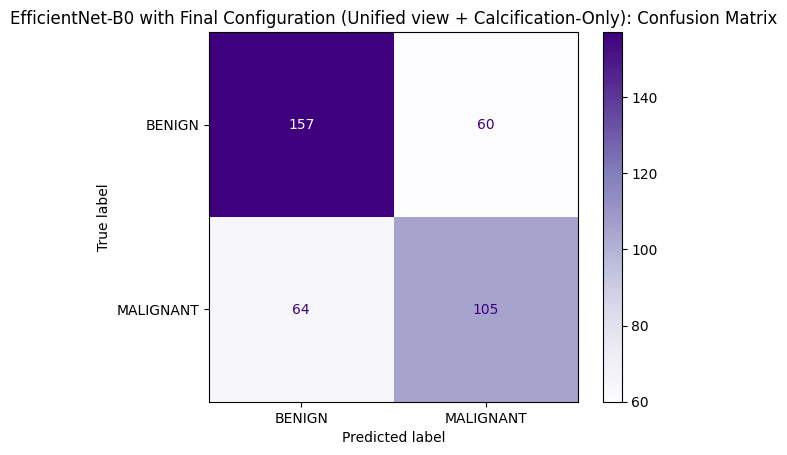

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_efficientnetb0, 'EfficientNet-B0', 'Final Configuration (Unified view + Calcification-Only)')

In [ ]:
# Save the trained model
efficientnetb0.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/efficientnetb0_final_configuration_unified_calcification.keras")